In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import PIL.Image as Image
import torch.utils.data as data
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from ipywidgets import interact, fixed
import os


In [2]:
PREFIX = '/kaggle/input/vesuvius-challenge-ink-detection/train/1'
BUFFER = 30
Z_START = 27
Z_DIM = 10
TRAINING_STEPS = 30000
LEARNING_RATE = 0.03
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VAL_EVERY = 3000

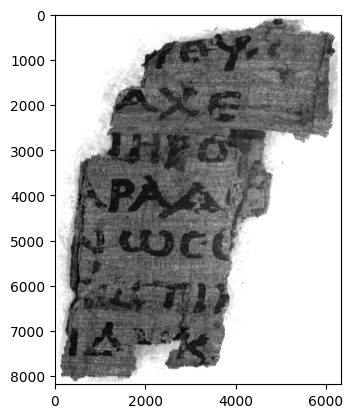

In [3]:
plt.imshow(Image.open(PREFIX + "/ir.png"), cmap="gray")
plt.show()
mask = np.array(Image.open(PREFIX + "/mask.png").convert('1'))
label = np.array(Image.open(PREFIX + "/inklabels.png"))
ir = np.array(Image.open(PREFIX + "/ir.png"))

tif_files = sorted(glob.glob(os.path.join(PREFIX, 'surface_volume', '*.tif')))

In [4]:
images = [
    np.array(Image.open(f), dtype=np.float32) / 65535.0
    for f in tif_files[Z_START:Z_START + Z_DIM]
]

image_stack = torch.stack([torch.from_numpy(img) for img in images], dim=0).to(DEVICE)

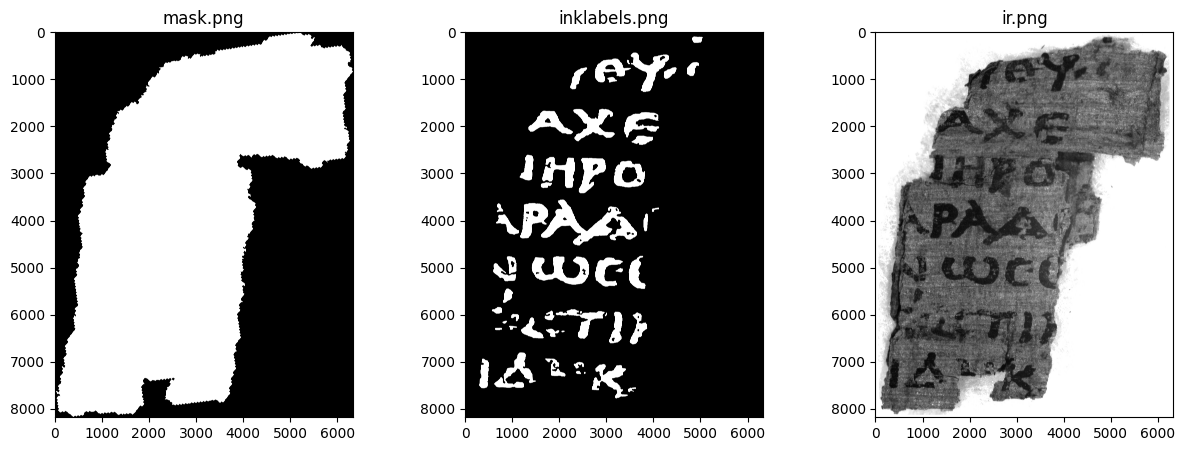

In [5]:
label = torch.from_numpy(label).float()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.set_title("mask.png")
ax1.imshow(mask, cmap='gray')
ax2.set_title("inklabels.png")
ax2.imshow(label.cpu().numpy(), cmap='gray')
ax3.set_title("ir.png")
ax3.imshow(ir, cmap='gray')
plt.show()

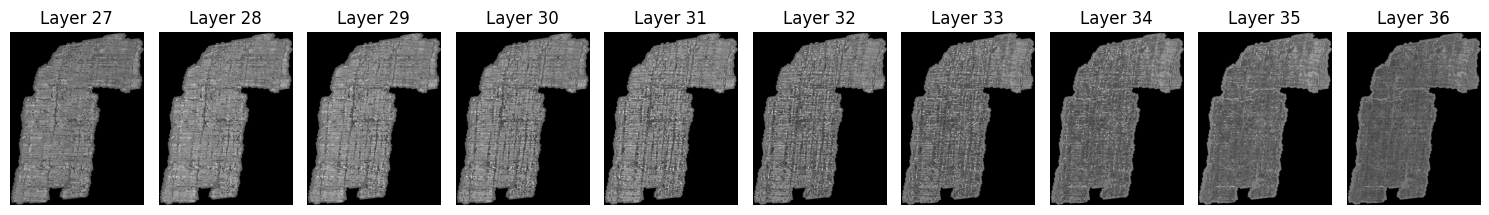

In [6]:
fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
for i, (image, ax) in enumerate(zip(images, axes)):
    img_uint8 = (image * 255).astype(np.uint8)
    pil_img = Image.fromarray(img_uint8)
    small_img = pil_img.resize((image.shape[1] // 16, image.shape[0] // 16))
    ax.imshow(small_img, cmap='gray')
    ax.set_title(f"Layer {Z_START + i}")
    ax.axis('off')
plt.tight_layout()
plt.show()

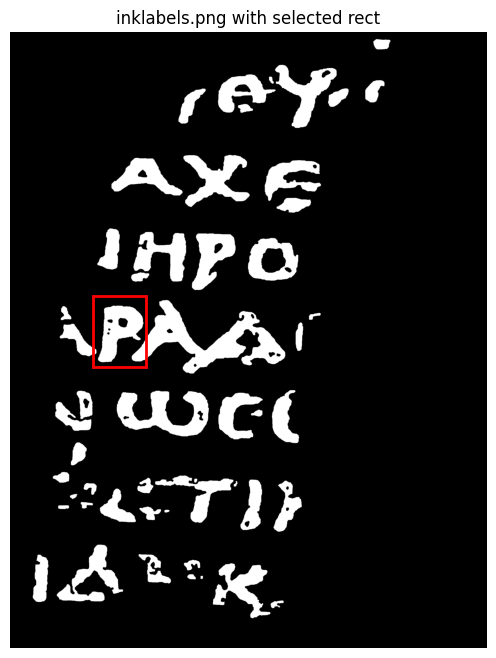

In [7]:
rect = (1100, 3500, 700, 950)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(label.cpu().numpy(), cmap='gray')
patch = patches.Rectangle(
    (rect[0], rect[1]), rect[2], rect[3],
    linewidth=2, edgecolor='r', facecolor='none'
)
ax.add_patch(patch)
ax.set_title("inklabels.png with selected rect")
ax.axis('off')
plt.show()

In [8]:
class SubvolumeDataset(data.Dataset):
    def __init__(self, image_stack, label, pixels):
        self.image_stack = image_stack
        self.label = label
        self.pixels = pixels

    def __len__(self):
        return len(self.pixels)

    def __getitem__(self, index):
        y, x = self.pixels[index]

        subvolume = self.image_stack[
            :, y-BUFFER:y+BUFFER+1, x-BUFFER:x+BUFFER+1
        ].view(1, Z_DIM, BUFFER*2+1, BUFFER*2+1)

        inklabel = torch.tensor(
            self.label[y, x],
            dtype=torch.float32
        ).view(1)

        return subvolume, inklabel

In [9]:
not_border = np.zeros(mask.shape, dtype=bool)
not_border[BUFFER:-BUFFER, BUFFER:-BUFFER] = True
valid_area = mask & not_border

inside_rect = np.zeros(mask.shape, dtype=bool)
inside_rect[rect[1]:rect[1]+rect[3], rect[0]:rect[0]+rect[2]] = True
inside_rect &= valid_area

outside_rect = valid_area & (~inside_rect)

pixels_train = np.argwhere(outside_rect)
pixels_val = np.argwhere(inside_rect)

In [10]:
train_loader = data.DataLoader(
    SubvolumeDataset(image_stack, label, pixels_train),
    batch_size=BATCH_SIZE, shuffle=True
)

val_loader = data.DataLoader(
    SubvolumeDataset(image_stack, label, pixels_val),
    batch_size=BATCH_SIZE, shuffle=False
)

In [11]:
model = nn.Sequential(
    nn.Conv3d(1, 16, 3, 1, 1), nn.MaxPool3d(2),
    nn.Conv3d(16, 32, 3, 1, 1), nn.MaxPool3d(2),
    nn.Conv3d(32, 64, 3, 1, 1), nn.MaxPool3d(2),
    nn.Flatten(1),
    nn.LazyLinear(128), nn.ReLU(),
    nn.LazyLinear(1)
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LEARNING_RATE*10, total_steps=TRAINING_STEPS
)

In [12]:
print("Training started...")
# =====================
train_losses = []
val_losses = []

model.train()
running_loss = 0.0

for step, (x, y) in enumerate(tqdm(train_loader, total=TRAINING_STEPS)):
    if step >= TRAINING_STEPS:
        break

    x, y = x.to(DEVICE), y.to(DEVICE)

    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    scheduler.step()

    running_loss += loss.item()

    if (step + 1) % VAL_EVERY == 0:
        train_loss = running_loss / VAL_EVERY
        train_losses.append(train_loss)
        running_loss = 0.0

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for vx, vy in val_loader:
                vx, vy = vx.to(DEVICE), vy.to(DEVICE)
                v_logits = model(vx)
                val_loss += criterion(v_logits, vy).item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Step {step+1} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")
        model.train()
print("Training completed!")


Training started...


  0%|          | 0/30000 [00:00<?, ?it/s]/tmp/ipykernel_24/1032650928.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inklabel = torch.tensor(
 10%|█         | 3006/30000 [03:15<44:46:11,  5.97s/it]

Step 3000 | Train Loss: 0.65958 | Val Loss: 0.82484


 20%|██        | 6007/30000 [06:26<31:21:16,  4.70s/it]

Step 6000 | Train Loss: 0.46736 | Val Loss: 0.91629


...

Step 27000 | Train Loss: 0.46598 | Val Loss: 0.80821


100%|██████████| 30000/30000 [31:58<00:00,  7.55s/it]

Step 30000 | Train Loss: 0.46525 | Val Loss: 0.84613


100%|██████████| 30000/30000 [31:58<00:00, 15.64it/s]

Training completed!
